In [1]:
from google.colab import drive # type: ignore
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import sys
print(sys.executable)   # should NOT be /usr/bin/python3

!nvidia-smi 

/usr/bin/python3
Mon May 25 17:58:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------------------------

In [6]:
# Brain segmentation dataset path
DATA_ROOT = "/content/drive/MyDrive/brain_segmentation_dataset/archive"

# Verify it's accessible
import os
print(os.listdir(DATA_ROOT))

['images', 'masks']


In [4]:
# Install required libraries
%pip install -q --upgrade pip
%pip install -q segmentation-models-pytorch==0.3.1
%pip install -q timm==0.4.12
%pip install -q albumentations==1.3.0
%pip install -q torchmetrics==0.11.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 45.0 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [5]:
import os, random, math, glob
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch                                            # type: ignore
import torch.nn as nn                                   # type: ignore
from torch.utils.data import Dataset, DataLoader        # type: ignore
import torchvision.transforms.functional as TF          # type: ignore

import albumentations as A                              # type: ignore
from albumentations.pytorch import ToTensorV2           # type: ignore

import segmentation_models_pytorch as smp               # type: ignore
import torchmetrics as tm                               # type: ignore                   

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [12]:
images_dir = Path(DATA_ROOT) / "images"
masks_dir = Path(DATA_ROOT) / "masks"

print("Images exists", images_dir.exists())
print("Masks exists", masks_dir.exists())

sample_images = list(images_dir.glob("*"))[:6]
print("sample_images count:", len(sample_images))

Images exists True
Masks exists True
sample_images count: 6


## Dataset class & transforms

In [10]:
# ============================================================
# DATASET CLASS
# ============================================================

class BrainTumorSegDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transforms=None):
        # Store list of file paths for images and masks
        # transforms: optional augmentation pipeline (albumentations)
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transforms = transforms

    def __len__(self):
        # Returns total number of samples in the dataset
        # PyTorch DataLoader uses this to know when to stop
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image and convert to RGB (3 channels: R, G, B)
        # Even if brain MRI is grayscale, RGB ensures 3 channels
        # which pretrained models (e.g. ResNet) expect
        img = np.array(Image.open(self.image_paths[idx]).convert("RGB"))

        # Load mask and convert to grayscale (1 channel)
        # Mask values: 0 = background, 255 = tumor
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"))

        # Binarize mask: pixel > 127 → 1 (tumor), else → 0 (background)
        # This handles any soft/anti-aliased edges in the mask
        # Result: binary mask with float32 values (0.0 or 1.0)
        mask = (mask > 127).astype("float32")

        if self.transforms:
            # Apply albumentations transforms to BOTH image and mask
            # Important: pass mask separately so spatial transforms
            # (flip, rotate) are applied consistently to both
            augmented = self.transforms(image=img, mask=mask)
            img = augmented['image']

            # unsqueeze(0): adds channel dim → shape (1, H, W)
            # needed because mask has no channel dim after augmentation
            mask = augmented['mask'].unsqueeze(0)
        else:
            # No transforms: manually convert to tensor
            img = TF.to_tensor(img)                      # (3, H, W), normalized to [0,1]
            mask = torch.tensor(mask).unsqueeze(0)       # (1, H, W)

        return img, mask   # img: (3,H,W)  mask: (1,H,W)


# ============================================================
# TRAINING TRANSFORMS (with augmentation)
# ============================================================

train_transform = A.Compose([
    # Resize all images to 256x256 — standardize input size
    A.Resize(256, 256),

    # Randomly flip image horizontally 50% of the time
    # Brain tumors can appear on either side → valid augmentation
    A.HorizontalFlip(p=0.5),

    # Randomly flip image vertically 20% of the time
    # Less common but adds variability
    A.VerticalFlip(p=0.2),

    # Randomly rotate image by 90° increments
    # Brain MRI orientation can vary across scanners
    A.RandomRotate90(p=0.5),

    # Randomly shift, scale, and rotate the image
    # shift_limit=0.05 → move image up to 5% in any direction
    # scale_limit=0.1  → zoom in/out up to 10%
    # rotate_limit=15  → rotate up to ±15 degrees
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),

    # Randomly change brightness and contrast
    # Simulates different MRI scanner settings
    # Helps model generalize across different hospitals/scanners
    A.RandomBrightnessContrast(p=0.4),

    # Normalize pixel values using ImageNet mean & std
    # mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)
    # Required if using pretrained backbone (e.g. ResNet, EfficientNet)
    A.Normalize(),

    # Convert numpy array → PyTorch tensor
    # Also reorders dims: (H,W,C) → (C,H,W)
    ToTensorV2()
])


# ============================================================
# VALIDATION TRANSFORMS (no augmentation)
# ============================================================

valid_transform = A.Compose([
    # Same resize as training — consistent input size
    A.Resize(256, 256),

    # Same normalization as training — must match!
    # Using different normalization would hurt performance
    A.Normalize(),

    # Convert to tensor: (H,W,C) → (C,H,W)
    ToTensorV2()

    # ❌ No flipping, rotating, or brightness changes
    # Validation should reflect real-world inference conditions
])

## Prepare train/val & dataloaders

In [13]:
# ============================================================
# STEP 1 — GET ALL FILE PATHS
# ============================================================

# glob("*") finds ALL files inside images_dir
# sorted() puts them in alphabetical order → consistent ordering
# Result: list of Path objects
# e.g. [Path("images/001.png"), Path("images/002.png"), ...]
all_images = sorted(list(images_dir.glob("*")))

# For each image, find its corresponding mask
# img.name gets just the filename e.g. "001.png"
# masks_dir / img.name → "masks/001.png"
# Assumes image and mask have the SAME filename!
# e.g. images/001.png ↔ masks/001.png
all_masks = [masks_dir / img.name for img in all_images]


# ============================================================
# STEP 2 — SPLIT INTO TRAIN & VALIDATION
# ============================================================

from sklearn.model_selection import train_test_split

# Splits data into 85% train, 15% validation
# test_size=0.15 → 15% goes to validation
# random_state=SEED → same split every run (reproducible)
# e.g. 3064 images → 2604 train, 460 validation
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    all_images, all_masks, test_size=0.15, random_state=SEED
)

#  Before split:        After split:
#  [img1, img2, ...]    Train: [img1, img3, ...] 85%
#                       Val:   [img2, img4, ...] 15%


# ============================================================
# STEP 3 — CREATE DATASET OBJECTS
# ============================================================

# Wraps file paths + transforms into a Dataset object
# train_ds uses train_transform → with augmentation (flip, rotate...)
# val_ds   uses valid_transform → no augmentation
train_ds = BrainTumorSegDataset(train_imgs, train_masks, transforms=train_transform)
val_ds   = BrainTumorSegDataset(val_imgs,   val_masks,   transforms=valid_transform)


# ============================================================
# STEP 4 — CREATE DATALOADERS
# ============================================================

BATCH_SIZE = 8  # process 8 images at a time

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,       # ✅ randomize order each epoch
                        #    prevents model memorizing the sequence
    num_workers=2,      # 2 CPU threads load data in background
                        #    so GPU never waits for data
    pin_memory=True     # faster CPU→GPU data transfer
                        #    keeps data in pinned memory
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,      # ❌ no shuffle for validation
                        #    we want consistent results each time
    num_workers=2,
    pin_memory=True
)

# Each "batch" = 8 images loaded together
# e.g. 2604 train images ÷ 8 = 326 batches per epoch
print("Train batches:", len(train_loader), "Val batches:", len(val_loader))

Train batches: 326 Val batches: 58


## Exploratory data analysis (EDA)
### Dataset statistics

Total images: 3064
Train: 2604 | Val: 460


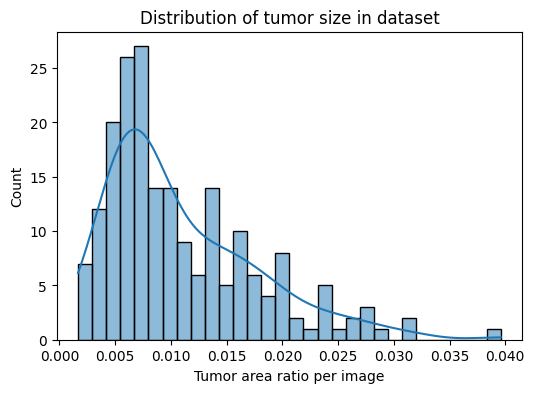

Mean tumor coverage: 1.10%


In [14]:
import seaborn as sns  # Seaborn — prettier statistical plots than matplotlib

# ============================================================
# STEP 1 — PRINT DATASET SUMMARY
# ============================================================

# Quick sanity check — make sure split looks correct
# e.g. Total: 3064 | Train: 2604 | Val: 460
print(f"Total images: {len(all_images)}")
print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)}")


# ============================================================
# STEP 2 — MEASURE TUMOR SIZE IN EACH MASK
# ============================================================

tumor_pixels = []  # stores tumor ratio for each image

# Only check first 200 masks (saves time, enough for overview)
# Remove [:200] if you want to check ALL images
for m in all_masks[:200]:

    # Load mask as grayscale (values 0-255)
    mask = np.array(Image.open(m).convert("L"))

    # Binarize: tumor=1, background=0
    # uint8 = integer type (0 or 1), needed for math below
    mask_bin = (mask > 127).astype(np.uint8)

    # Calculate what % of image is tumor
    # mask_bin.sum()  = number of tumor pixels (1s)
    # mask_bin.size   = total pixels (H × W)
    # ratio = 0.0 → no tumor, 1.0 → entire image is tumor
    # e.g. 500 tumor pixels / 65536 total = 0.0076 (0.76%)
    ratio = mask_bin.sum() / mask_bin.size

    tumor_pixels.append(ratio)


# ============================================================
# STEP 3 — PLOT DISTRIBUTION
# ============================================================

plt.figure(figsize=(6, 4))   # 6 inches wide, 4 inches tall

# histplot: bar chart showing how many images have each tumor ratio
# bins=30: divide the range into 30 bars
# kde=True: draw smooth curve over the bars
#           KDE = Kernel Density Estimation
sns.histplot(tumor_pixels, bins=30, kde=True)

plt.xlabel("Tumor area ratio per image")  # x-axis label
plt.ylabel("Count")                        # y-axis label
plt.title("Distribution of tumor size in dataset")
plt.show()


# ============================================================
# STEP 4 — PRINT AVERAGE TUMOR COVERAGE
# ============================================================

# np.mean() = average of all ratios
# × 100 → convert to percentage
# :.2f → show 2 decimal places
# e.g. "Mean tumor coverage: 3.45%"
print(f"Mean tumor coverage: {np.mean(tumor_pixels)*100:.2f}%")

### Tumor Size Distribution

#### Source
- Dataset: Brain Tumor Segmentation Dataset
- Sample analyzed: 200 images (subset)
- Analysis date: May 2026

---

#### Chart Overview

- **X-axis**: Tumor area ratio per image (0.000 → 0.040)
- **Y-axis**: Number of images (Count)
- **Blue bars**: Histogram (frequency distribution)
- **Blue curve**: KDE — smooth estimate of distribution shape

---

#### Key Statistics

| Metric | Value |
|---|---|
| Tumor ratio range | 0.000 – 0.040 |
| Most common ratio | 0.005 – 0.010 |
| Peak count | ~26 images |
| Maximum observed | ~0.040 (4%) |
| Distribution shape | Right-skewed |

---

#### Observations

##### 1. Tumor Region is Extremely Small
- The majority of images have tumor occupying
  only **0.5% – 1%** of total image area
- Very few images exceed a tumor ratio of **0.025**

##### 2. Right-Skewed Distribution
- The distribution has a **long tail** to the right
- Most images cluster at the low end (small tumors)
- Large tumor cases are rare outliers

##### 3. Pixel-Level Imbalance

| Class | Pixel Coverage |
|---|---|
| Background | ~99% |
| Tumor | ~1% |

##### 4. High Variance in Tumor Size
- Tumor ratios range from near **0%** to **4%**
- Significant variation across patients
- No clear "typical" tumor size — wide spread

---

#### Raw Numbers (Estimated from Chart)

| Ratio Range | Approx. Image Count |
|---|---|
| 0.000 – 0.005 | ~40 images |
| 0.005 – 0.010 | ~80 images |
| 0.010 – 0.015 | ~30 images |
| 0.015 – 0.020 | ~20 images |
| 0.020 – 0.040 | ~30 images |

---

#### Summary

> Tumor regions occupy a **very small fraction** of total image area,
> typically between 0.5% and 1%. The distribution is heavily
> right-skewed, indicating that **small tumors dominate** the dataset
> while large tumor cases are rare. This results in a significant
> pixel-level imbalance between tumor and background classes.

---

*Sample: 200 images | Dataset: Brain Tumor Segmentation*

## Visualize random samples

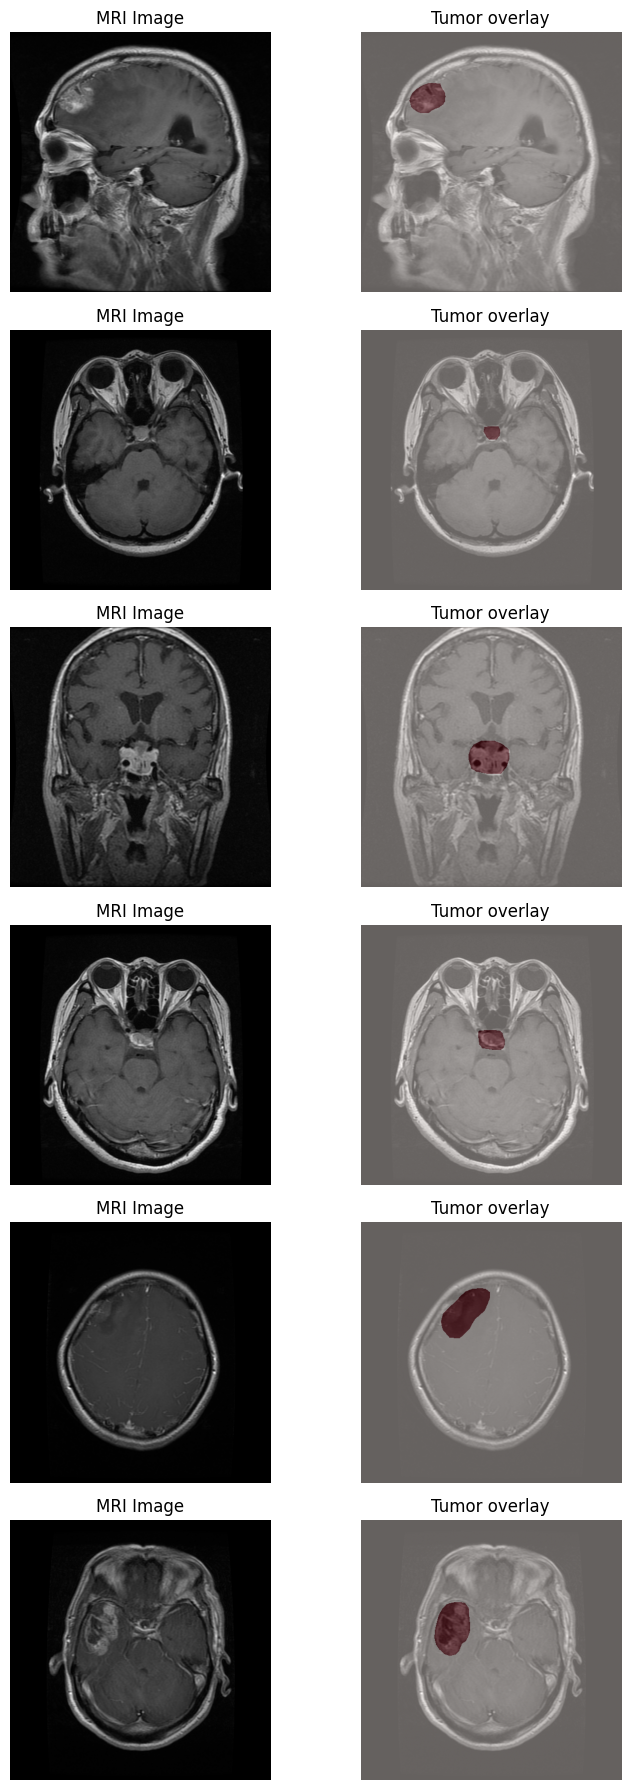

In [15]:
import random

n_samples = 6
fig, axs = plt.subplots(n_samples, 2, figsize=(8, 3*n_samples))

for i in range(n_samples):
    idx = random.randint(0, len(all_images)-1)
    img = np.array(Image.open(all_images[idx]).convert("RGB"))
    mask = np.array(Image.open(all_masks[idx]).convert("L"))
    mask_bin = (mask > 127).astype(np.uint8)

    axs[i,0].imshow(img)
    axs[i,0].set_title("MRI Image")
    axs[i,0].axis("off")

    axs[i,1].imshow(img)
    axs[i,1].imshow(mask_bin, cmap="Reds", alpha=0.4) 
    axs[i,1].set_title("Tumor overlay")
    axs[i,1].axis("off")

plt.tight_layout()
plt.show()

## Model, Loss, Optimizer, Metrics

In [16]:
# ============================================================
# STEP 1 — DEFINE THE MODEL
# ============================================================

ENCODER = "resnet34"          # backbone network that extracts features
                              # ResNet34 = 34-layer deep neural network
                              # acts as the "eyes" of the model

ENCODER_WEIGHTS = "imagenet"  # start with weights pre-trained on ImageNet
                              # ImageNet = 1.4M natural images
                              # transfer learning: reuse learned features
                              # instead of learning from scratch

ACTIVATION = None             # no activation at output layer
                              # raw scores (logits) are output
                              # sigmoid/threshold applied separately later

model = smp.Unet(
    encoder_name=ENCODER,          # use ResNet34 as backbone
    encoder_weights=ENCODER_WEIGHTS,  # load ImageNet pretrained weights
    in_channels=3,                 # input = 3 channel RGB image
                                   # (Red, Green, Blue)

    classes=1,                     # HOW MANY THINGS to detect
                                   # classes=1 → only "tumor vs background"
                                   # model answers YES/NO for each pixel:
                                   #   1 = tumor
                                   #   0 = background
                                   # if classes=3 → model would output
                                   # 3 scores per pixel (e.g. necrosis,
                                   # edema, enhancing tumor)

    activation=ACTIVATION          # no activation → raw logits output
                                   # logits = raw scores before converting
                                   # to probabilities
                                   # e.g. logit=2.5 means "pretty sure tumor"
                                   #      logit=-1.0 means "probably background"
)

model.to(DEVICE)
# move model to GPU if available
# GPU trains ~10-50x faster than CPU for images


# ============================================================
# STEP 2 — DICE LOSS
# ============================================================

# First understand what DICE means:
#
# Dice measures OVERLAP between prediction and ground truth
#
# Perfect prediction:          Bad prediction:
# Pred:   ░░██░░               Pred:   ░░░░░░
# Target: ░░██░░               Target: ░░██░░
# Overlap: 100% → Dice=1.0     Overlap: 0% → Dice=0.0
#
# Formula:
#         2 × overlap
# Dice = ─────────────────────
#         pred area + true area
#
# Why Dice for medical images?
# BCE (normal loss) treats all pixels equally
# → 99% background pixels dominate training
# → model ignores tumor (only 1% of pixels)
# Dice only cares about OVERLAP
# → forces model to find tumor region

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        # smooth: tiny number added to prevent dividing by zero
        # e.g. image with NO tumor → union=0 → would crash without smooth
        self.smooth = smooth

    def forward(self, preds, targets):
        # preds currently = raw logits (can be any number)
        # sigmoid squashes them to 0.0 → 1.0 (probability)
        # e.g. logit= 3.0 → sigmoid → 0.95 (95% sure it's tumor)
        #      logit=-2.0 → sigmoid → 0.12 (12% sure it's tumor)
        preds = torch.sigmoid(preds)

        # flatten: collapse H and W into one dimension
        # before: (8, 1, 256, 256) = 8 images, 1 channel, 256×256 pixels
        # after:  (8, 65536)       = 8 images, 65536 pixels each
        # easier to do math across all pixels at once
        preds   = preds.view(preds.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        # intersection = pixels where BOTH pred AND target = tumor
        # multiply pixel by pixel:
        #   pred=0.9, target=1.0 → 0.9×1.0 = 0.9 (good prediction)
        #   pred=0.1, target=1.0 → 0.1×1.0 = 0.1 (bad prediction)
        #   pred=0.9, target=0.0 → 0.9×0.0 = 0.0 (false alarm)
        # .sum(1) = add up all pixels for each image
        intersection = (preds * targets).sum(1)

        # union = total predicted tumor + total actual tumor
        union = preds.sum(1) + targets.sum(1)

        # Dice score: how much overlap vs total area
        # range: 0.0 (no overlap) → 1.0 (perfect overlap)
        dice = (2 * intersection + self.smooth) / (union + self.smooth)

        # return LOSS = 1 - dice
        # we always MINIMIZE loss during training
        # so: perfect overlap → dice=1.0 → loss=0.0 ✅
        #     no overlap      → dice=0.0 → loss=1.0 ❌
        return 1 - dice.mean()


# ============================================================
# STEP 3 — COMBINED LOSS FUNCTION
# ============================================================

# BCE = Binary Cross Entropy
# looks at EACH pixel independently
# "how wrong was your prediction for THIS pixel?"
# weakness: background pixels (99%) dominate
#           model learns to ignore tumor
bce = nn.BCEWithLogitsLoss()

# Dice Loss (defined above)
# looks at OVERALL OVERLAP
# "how well did you find the tumor region?"
# strength: doesn't care about background pixels
#           forces model to find tumor
dice = DiceLoss()

def loss_fn(preds, targets):
    # combine both losses equally (50/50)
    # BCE  → stable training, pixel accuracy
    # Dice → tumor focus, handles 1% imbalance
    #
    # think of it as two teachers grading together:
    # Teacher 1 (BCE):  "get each pixel right"
    # Teacher 2 (Dice): "find the tumor region"
    return 0.5 * bce(preds, targets) + 0.5 * dice(preds, targets)


# ============================================================
# STEP 4 — OPTIMIZER
# ============================================================

# optimizer = decides HOW to update model weights after each batch
# AdamW = most popular optimizer for deep learning
#
# analogy: model is lost in mountains (high loss = high altitude)
# optimizer = GPS guiding it downhill toward lowest point (low loss)
#
# lr = learning rate = step size when walking downhill
#   lr too HIGH → takes huge steps → overshoots, never finds bottom
#   lr too LOW  → tiny steps → takes forever to converge
#   lr=1e-3 (0.001) is a safe starting point
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)


# ============================================================
# STEP 5 — LEARNING RATE SCHEDULER
# ============================================================

# scheduler = automatically adjusts lr during training
# ReduceLROnPlateau = reduce lr when model stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',      # watching for loss to go DOWN (minimize)
    factor=0.5,      # when triggered: lr = lr × 0.5
                     # e.g. 0.001 → 0.0005 → 0.00025
    patience=3       # wait 3 epochs before reducing
                     # gives model a chance to improve on its own
)
# why reduce lr over time?
# early training: big steps to find the right direction quickly
# late training:  small steps to fine-tune without overshooting
#
# Epoch 1-3:  lr=0.001   (learning fast)
# Epoch 4-6:  lr=0.0005  (slowing down)
# Epoch 7-9:  lr=0.00025 (fine tuning)


# ============================================================
# STEP 6 — EVALUATION METRIC (IoU)
# ============================================================

import torchmetrics         # type: ignore                    

# IoU = Intersection over Union
# also called Jaccard Index
# standard metric for segmentation tasks in research papers
#
# visual explanation:
#
#   Ground truth:    Prediction:      Overlap:
#   ┌───────┐        ┌───────┐        ┌───────┐
#   │ ████  │        │  ████ │        │  ██   │
#   │ ████  │   +    │  ████ │   =    │  ██   │
#   └───────┘        └───────┘        └───────┘
#   (what doctor     (what model      (intersection)
#    drew)            predicted)
#
#          intersection (overlap area)
# IoU =  ──────────────────────────────
#          union (total combined area)
#
# range: 0.0 (completely wrong) → 1.0 (perfect)
# IoU vs Dice:
#   both measure overlap
#   IoU is stricter → lower values → used in benchmarks
#   Dice is gentler → higher values → used in loss function
#
# task="binary" → two classes only (tumor=1, background=0)
# .to(DEVICE)   → run on GPU alongside model
metric_iou = torchmetrics.JaccardIndex(task="binary").to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 265MB/s]


## Training & validation loops

Training data (2604 images)
         │
         ▼
┌─────────────────────┐
│   train_one_epoch   │
│                     │
│  for each batch:    │
│  1. forward pass    │  ← model predicts
│  2. calculate loss  │  ← how wrong?
│  3. backward pass   │  ← calculate gradients
│  4. update weights  │  ← model learns
└─────────────────────┘
         │
         ▼
┌─────────────────────┐
│  valid_one_epoch    │
│                     │
│  for each batch:    │
│  1. forward pass    │  ← model predicts
│  2. calculate loss  │  ← how wrong?
│  3. calculate IoU   │  ← how well tumor found?
│  (NO weight update) │  ← model does NOT learn
└─────────────────────┘
         │
         ▼
   scheduler.step()   ← reduce lr if no improvement
         │
         ▼
   save to history    ← for plotting
         │
         ▼
   repeat × 12 epochs

Epoch 1/12


Train:   0%|          | 0/326 [00:00<?, ?it/s]

Val:   0%|          | 0/58 [00:00<?, ?it/s]

Train loss: 0.3977  Val loss: 0.2297  Val IoU: 0.4989
Epoch 2/12


Train:   0%|          | 0/326 [00:00<?, ?it/s]

...

Train loss: 0.1668  Val loss: 0.1436  Val IoU: 0.6631
Epoch 12/12


Train:   0%|          | 0/326 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0ed43be340>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7d0ed43be340>^
Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^self._shutdown_workers()^^

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        if w.is_alive():assert self._parent_pid == os.getpid(), 'can only test a child process'

           ^ ^ ^ ^ ^ ^ ^ ^^^^^^^^^^
^  File

Val:   0%|          | 0/58 [00:00<?, ?it/s]

Train loss: 0.1593  Val loss: 0.1537  Val IoU: 0.6432


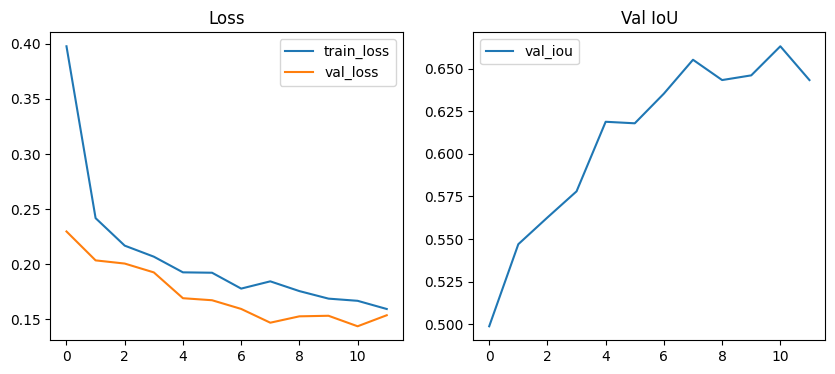

In [17]:
# tqdm = progress bar library
# shows a live progress bar while looping through batches
# e.g. Train: 45%|████████░░░░| 147/326 [02:13<02:41]
from tqdm.auto import tqdm


# ============================================================
# STEP 1 — TRAINING FUNCTION (one full pass through train data)
# ============================================================

def train_one_epoch(loader, model, optimizer):

    # set model to TRAINING mode
    # enables: dropout, batch normalization behaves differently
    # always call before training loop
    model.train()

    running_loss = 0.0  # accumulates total loss across all batches

    # loop through batches of 8 images at a time
    # tqdm wraps loader to show progress bar
    for imgs, masks in tqdm(loader, desc="Train"):

        # move data to GPU (same device as model)
        # data must be on same device as model or it crashes
        imgs  = imgs.to(DEVICE)   # shape: (8, 3, 256, 256)
        masks = masks.to(DEVICE)  # shape: (8, 1, 256, 256)

        # FORWARD PASS
        # send images through model → get predictions
        # preds = raw logits (not yet probabilities)
        preds = model(imgs)       # shape: (8, 1, 256, 256)

        # calculate how wrong the predictions are
        # uses combined BCE + Dice loss defined earlier
        loss = loss_fn(preds, masks)

        # BACKWARD PASS (how model learns)
        # step 1: clear old gradients from previous batch
        #         must do this or gradients accumulate incorrectly
        optimizer.zero_grad()

        # step 2: calculate gradients
        #         "how should each weight change to reduce loss?"
        #         works backwards through the network
        loss.backward()

        # step 3: update model weights using gradients
        #         takes one step downhill toward lower loss
        optimizer.step()

        # accumulate loss for this batch
        # loss.item() = loss value as plain number
        # × imgs.size(0) = multiply by batch size (8)
        # because last batch might be smaller than 8
        running_loss += loss.item() * imgs.size(0)

    # return AVERAGE loss per image across entire epoch
    return running_loss / len(loader.dataset)


# ============================================================
# STEP 2 — VALIDATION FUNCTION (check performance on val data)
# ============================================================

def valid_one_epoch(loader, model):

    # set model to EVALUATION mode
    # disables: dropout, batch norm uses running statistics
    # model stops learning → just predicting
    model.eval()

    running_loss = 0.0
    iou_score    = 0.0

    # torch.no_grad() = don't calculate gradients
    # saves memory and speeds up validation
    # we don't need gradients because we're not updating weights
    with torch.no_grad():

        for imgs, masks in tqdm(loader, desc="Val"):
            imgs  = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            # forward pass only (no backward pass in validation)
            preds = model(imgs)
            loss  = loss_fn(preds, masks)
            running_loss += loss.item() * imgs.size(0)

            # convert logits → probabilities (0.0 to 1.0)
            probs = torch.sigmoid(preds)

            # convert probabilities → binary prediction (0 or 1)
            # threshold = 0.5:
            #   prob > 0.5 → 1 (tumor)
            #   prob ≤ 0.5 → 0 (background)
            preds_bin = (probs > 0.5).int()

            # convert masks to int for IoU calculation
            masks_int = masks.int()

            # calculate IoU for each image individually
            # zip pairs each prediction with its ground truth mask
            for p, t in zip(preds_bin, masks_int):

                # squeeze(0) removes channel dimension
                # (1, 256, 256) → (256, 256)
                # metric_iou expects 2D input
                i = metric_iou(p.squeeze(0), t.squeeze(0))
                iou_score += i.item()

    # average loss and IoU across all validation images
    avg_loss = running_loss / len(loader.dataset)
    avg_iou  = iou_score   / len(loader.dataset)
    return avg_loss, avg_iou


# ============================================================
# STEP 3 — TRAINING LOOP
# ============================================================

EPOCHS = 12  # number of times to go through ALL training data
             # 1 epoch = model sees every training image once
             # 12 epochs = model sees every image 12 times

# dictionary to store metrics for plotting later
history = {
    "train_loss": [],  # training loss per epoch
    "val_loss":   [],  # validation loss per epoch
    "val_iou":    []   # validation IoU per epoch
}

# loop through each epoch
for epoch in range(1, EPOCHS+1):
    print(f"Epoch {epoch}/{EPOCHS}")

    # TRAIN: model learns from training data
    tr_loss = train_one_epoch(train_loader, model, optimizer)

    # VALIDATE: check performance on unseen data
    # model does NOT learn here → just measuring performance
    val_loss, val_iou = valid_one_epoch(val_loader, model)

    # tell scheduler the current validation loss
    # if no improvement for 3 epochs → reduce learning rate
    scheduler.step(val_loss)

    # save metrics to history for plotting
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)

    # print summary for this epoch
    # :.4f = show 4 decimal places
    print(f"Train loss: {tr_loss:.4f}  Val loss: {val_loss:.4f}  Val IoU: {val_iou:.4f}")

    # what good progress looks like:
    # Epoch 1:  Train loss: 0.6821  Val loss: 0.6543  Val IoU: 0.312
    # Epoch 6:  Train loss: 0.4231  Val loss: 0.4187  Val IoU: 0.521
    # Epoch 12: Train loss: 0.3012  Val loss: 0.3156  Val IoU: 0.634


# ============================================================
# STEP 4 — PLOT TRAINING HISTORY
# ============================================================

plt.figure(figsize=(10, 4))  # wide figure with 2 side-by-side plots

# LEFT PLOT: Loss curves
plt.subplot(1, 2, 1)         # 1 row, 2 cols, plot #1
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"],   label="val_loss")
plt.legend()
plt.title("Loss")
# what to look for:
# ✅ both curves going DOWN = model is learning
# ❌ train_loss down but val_loss UP = overfitting
#    (model memorized training data, fails on new data)

# RIGHT PLOT: IoU curve
plt.subplot(1, 2, 2)         # 1 row, 2 cols, plot #2
plt.plot(history["val_iou"], label="val_iou")
plt.legend()
plt.title("Val IoU")
# what to look for:
# ✅ IoU going UP = model getting better at finding tumors
# ❌ IoU flat or dropping = model not improving

plt.show()

## Visualization utilities

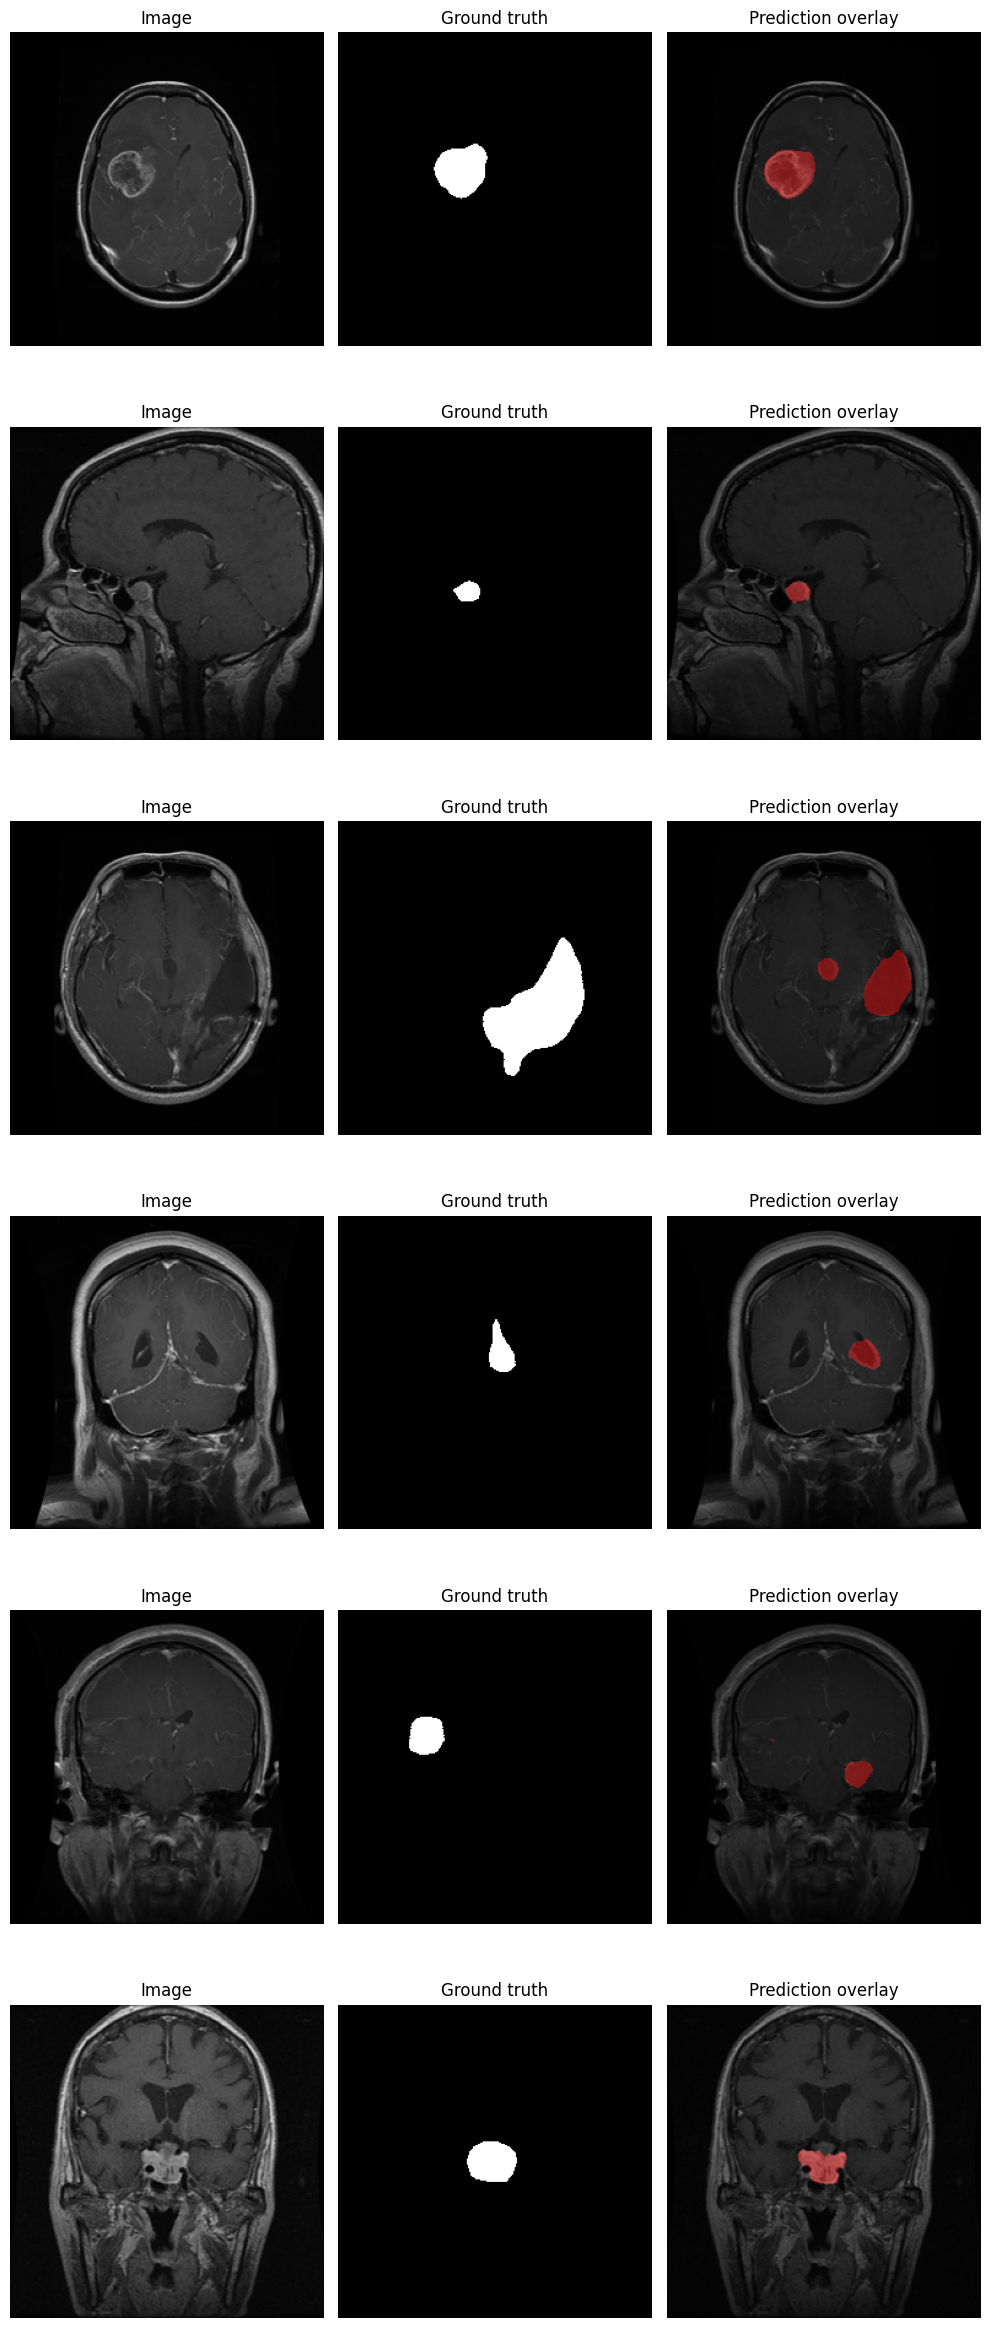

In [18]:
def overlay_mask_on_image(image, mask, alpha=0.4):
    import cv2  # type: ignore        
    img = image.copy()
    mask_color = np.zeros_like(img)
    mask_color[..., 0] = (mask * 255).astype(np.uint8)  
    overlay = cv2.addWeighted(img, 1-alpha, mask_color, alpha, 0)
    return overlay

model.eval()
n_show = 6
fig, axs = plt.subplots(n_show, 3, figsize=(10, 4*n_show))
for i in range(n_show):
    img_path = val_imgs[i]
    mask_path = val_masks[i]
    img_np = np.array(Image.open(img_path).convert("RGB").resize((256,256)))
    mask_np = np.array(Image.open(mask_path).convert("L").resize((256,256))) > 127
    input_t = valid_transform(image=img_np)["image"].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = model(input_t)
        pred_prob = torch.sigmoid(pred).squeeze().cpu().numpy()
        pred_bin = pred_prob > 0.5
    overlay = overlay_mask_on_image(img_np, pred_bin)
    axs[i,0].imshow(img_np); axs[i,0].set_title("Image"); axs[i,0].axis("off")
    axs[i,1].imshow(mask_np, cmap="gray"); axs[i,1].set_title("Ground truth"); axs[i,1].axis("off")
    axs[i,2].imshow(overlay); axs[i,2].set_title("Prediction overlay"); axs[i,2].axis("off")
plt.tight_layout()
plt.show()

## Extended Visualizations with heatmaps and contours

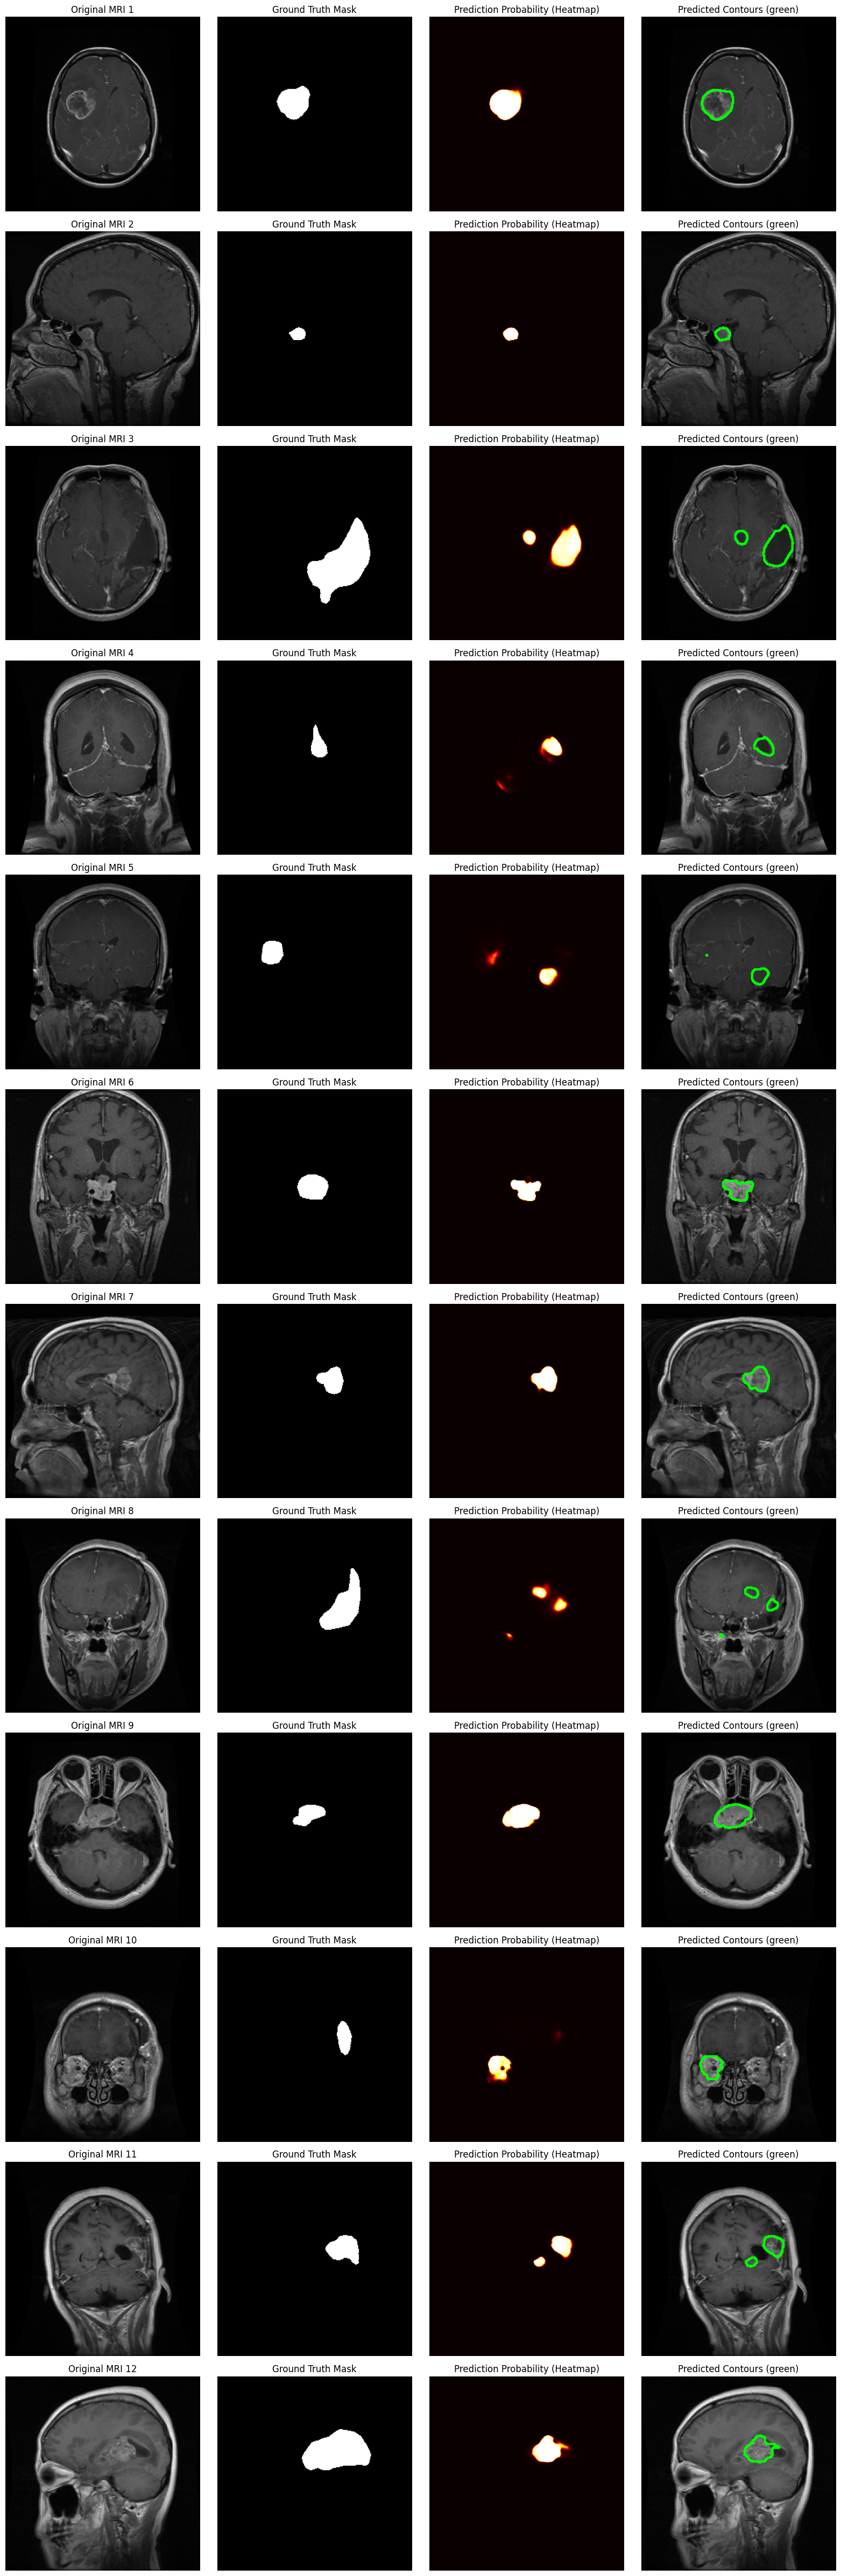

In [19]:
import matplotlib.patches as patches

def visualize_predictions(model, img_paths, mask_paths, n_samples=12):
    model.eval()
    fig, axs = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))

    for i in range(n_samples):
        img_path = img_paths[i]
        mask_path = mask_paths[i]

        img_np = np.array(Image.open(img_path).convert("RGB").resize((256,256)))
        mask_np = np.array(Image.open(mask_path).convert("L").resize((256,256))) > 127

        input_t = valid_transform(image=img_np)["image"].unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            pred = model(input_t)
            pred_prob = torch.sigmoid(pred).squeeze().cpu().numpy()
            pred_bin = pred_prob > 0.5

        overlay_pred = overlay_mask_on_image(img_np, pred_bin)

        contours, _ = cv2.findContours(pred_bin.astype("uint8"), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour_img = img_np.copy()
        cv2.drawContours(contour_img, contours, -1, (0,255,0), 2)

        axs[i,0].imshow(img_np)
        axs[i,0].set_title(f"Original MRI {i+1}")
        axs[i,0].axis("off")

        axs[i,1].imshow(mask_np, cmap="gray")
        axs[i,1].set_title("Ground Truth Mask")
        axs[i,1].axis("off")

        axs[i,2].imshow(pred_prob, cmap="hot")
        axs[i,2].set_title("Prediction Probability (Heatmap)")
        axs[i,2].axis("off")

        axs[i,3].imshow(contour_img)
        axs[i,3].set_title("Predicted Contours (green)")
        axs[i,3].axis("off")

    plt.tight_layout()
    plt.show()


visualize_predictions(model, val_imgs, val_masks, n_samples=12)

In [20]:
# Save to Google Drive so you can download it
torch.save(model.state_dict(), "/content/drive/MyDrive/brain_segmentation_dataset/brain_tumor_unet_resnet34.pth")
print("Model saved!")

Model saved!
